   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years  sales  \
0                   3              0     1                      0  sales   
1                   6              0     1                      0  sales   
2                   4              0     1                      0  sales   
3                   5              0     1                      0  sales   
4                   3              0     1                      0  sales   

   salary  
0     low  
1  medium  
2  medium  
3     low  
4 

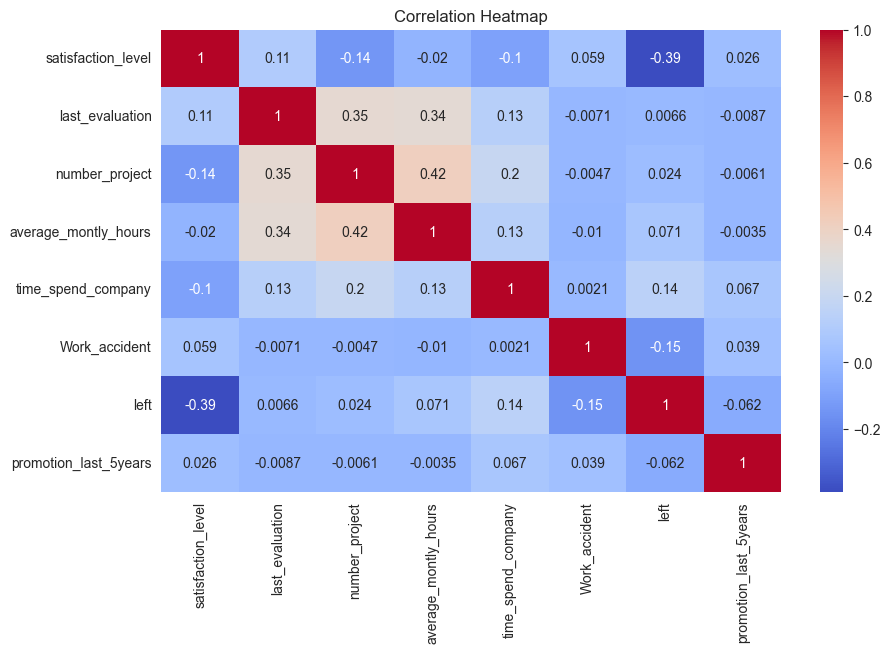

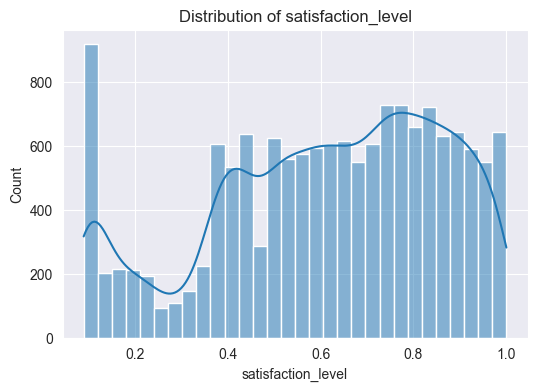

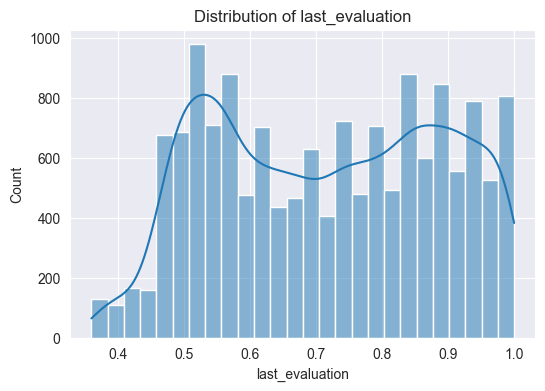

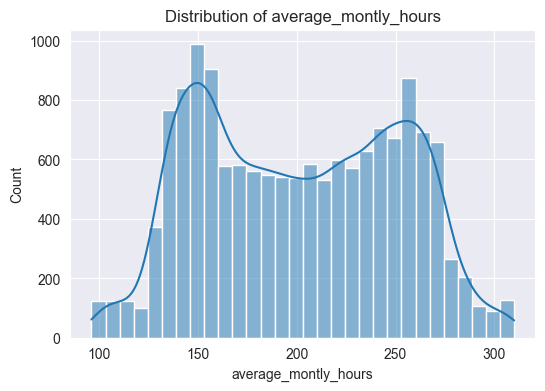

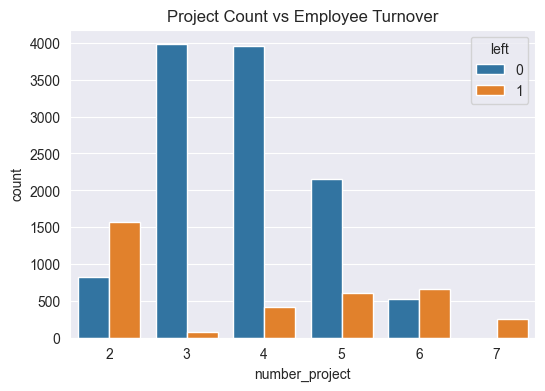

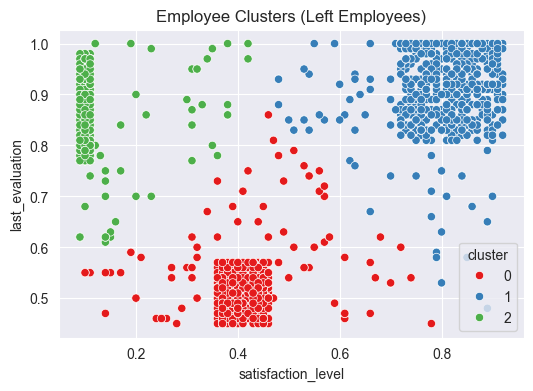


Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.81      0.77      0.79      9142
           1       0.78      0.82      0.80      9142

    accuracy                           0.80     18284
   macro avg       0.80      0.80      0.79     18284
weighted avg       0.80      0.80      0.79     18284

ROC-AUC: 0.862

Model: Random Forest
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      9142
           1       1.00      0.97      0.98      9142

    accuracy                           0.98     18284
   macro avg       0.98      0.98      0.98     18284
weighted avg       0.98      0.98      0.98     18284

ROC-AUC: 0.998

Model: Gradient Boosting
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      9142
           1       0.98      0.95      0.96      9142

    accuracy                           0.96     18284
   macro avg       0.9

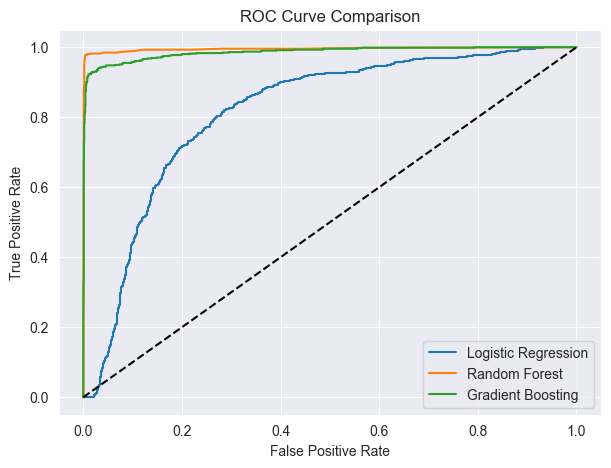


Confusion Matrix – Logistic Regression
[[1767  519]
 [ 184  530]]

Confusion Matrix – Random Forest
[[2271   15]
 [  16  698]]

Confusion Matrix – Gradient Boosting
[[2228   58]
 [  50  664]]

Best Model: Random Forest
       turnover_probability risk_zone
10627                  0.00     Green
2703                   0.58    Yellow
6059                   0.06     Green
3258                   0.01     Green
4565                   0.00     Green


In [1]:
# Employee Turnover Analytics – End-to-End Machine Learning Project
# Dataset: HR_comma_sep.csv
# Target: left (0 = Stayed, 1 = Left)

# ============================
# 1. Import Libraries
# ============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

from imblearn.over_sampling import SMOTE

# ============================
# 2. Load Dataset
# ============================
df = pd.read_csv('HR_comma_sep.csv')

print(df.head())
print(df.info())

# ============================
# 3. Data Quality Checks
# ============================
print("\nMissing Values:\n", df.isnull().sum())

print("\nClass Distribution:\n", df['left'].value_counts(normalize=True))

# ============================
# 4. Exploratory Data Analysis (EDA)
# ============================

# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Distribution Plots
features = ['satisfaction_level', 'last_evaluation', 'average_montly_hours']

for col in features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

# Bar Plot: Projects vs Turnover
plt.figure(figsize=(6,4))
sns.countplot(x='number_project', hue='left', data=df)
plt.title('Project Count vs Employee Turnover')
plt.show()

# ============================
# 5. Clustering Employees Who Left
# ============================
from sklearn.cluster import KMeans

cluster_df = df[df['left'] == 1][['satisfaction_level', 'last_evaluation']]

kmeans = KMeans(n_clusters=3, random_state=42)
cluster_df['cluster'] = kmeans.fit_predict(cluster_df)

plt.figure(figsize=(6,4))
sns.scatterplot(
    x='satisfaction_level', y='last_evaluation',
    hue='cluster', data=cluster_df, palette='Set1'
)
plt.title('Employee Clusters (Left Employees)')
plt.show()

# ============================
# 6. Data Preprocessing
# ============================

X = df.drop('left', axis=1)
y = df['left']

categorical_cols = ['sales', 'salary']
numerical_cols = X.drop(categorical_cols, axis=1).columns

X_cat = pd.get_dummies(X[categorical_cols], drop_first=True)
X_num = X[numerical_cols]

X_final = pd.concat([X_num, X_cat], axis=1)

# ============================
# 7. Train-Test Split
# ============================

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, stratify=y, random_state=123
)

# ============================
# 8. Handle Class Imbalance using SMOTE
# ============================

smote = SMOTE(random_state=123)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# ============================
# 9. Model Training with 5-Fold CV
# ============================

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=123),
    'Gradient Boosting': GradientBoostingClassifier(random_state=123)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

roc_results = {}

for name, model in models.items():
    print(f"\nModel: {name}")
    y_pred_cv = cross_val_predict(
        model, X_train_sm, y_train_sm,
        cv=cv, method='predict'
    )
    y_prob_cv = cross_val_predict(
        model, X_train_sm, y_train_sm,
        cv=cv, method='predict_proba'
    )[:,1]

    print(classification_report(y_train_sm, y_pred_cv))
    roc_auc = roc_auc_score(y_train_sm, y_prob_cv)
    roc_results[name] = roc_auc
    print(f"ROC-AUC: {roc_auc:.3f}")

# ============================
# 10. ROC Curve Plot
# ============================

plt.figure(figsize=(7,5))

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_test_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_test_prob)
    plt.plot(fpr, tpr, label=f'{name}')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

# ============================
# 11. Confusion Matrices
# ============================

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)
    print(f"\nConfusion Matrix – {name}")
    print(confusion_matrix(y_test, y_pred))

# ============================
# 12. Best Model Selection
# ============================

best_model_name = max(roc_results, key=roc_results.get)
best_model = models[best_model_name]
best_model.fit(X_train_sm, y_train_sm)

print(f"\nBest Model: {best_model_name}")

# ============================
# 13. Predict Turnover Probability
# ============================

test_probs = best_model.predict_proba(X_test)[:,1]

def risk_zone(p):
    if p < 0.2:
        return 'Green'
    elif p < 0.6:
        return 'Yellow'
    elif p < 0.9:
        return 'Orange'
    else:
        return 'Red'

risk_df = X_test.copy()
risk_df['turnover_probability'] = test_probs
risk_df['risk_zone'] = risk_df['turnover_probability'].apply(risk_zone)

print(risk_df[['turnover_probability', 'risk_zone']].head())

# ============================
# END OF NOTEBOOK
# ============================
